In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])

In [31]:
model = Sequential()
model.add(Dense(8, input_dim=2, activation='relu'))
model.add(Dense(4, input_dim=1, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X, y, epochs=500, verbose=0)

In [32]:
def plot_decision_boundary(model, X, y, ax, title):
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 100), np.linspace(-0.5, 1.5, 100))
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    Z = model.predict(grid, verbose=0)
    Z = (Z > 0.5).astype(int)
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k', s=100)
    ax.set_title(title)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")



ANN Accuracy: 100.0%


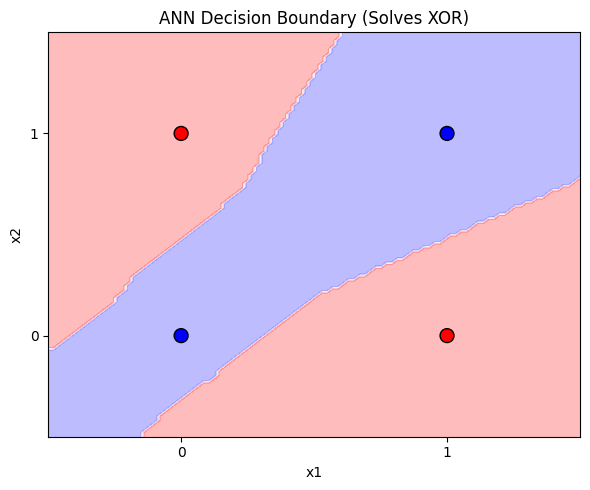

In [33]:
fig, ax1 = plt.subplots(figsize=(6, 5))

plot_decision_boundary(model, X, y, ax1, "ANN Decision Boundary (Solves XOR)")

_, accuracy = model.evaluate(X, y, verbose=0)
print(f"ANN Accuracy: {accuracy * 100}%")

plt.tight_layout()
plt.show()